# Categorical Encoding Showdown
### Stop Using One-Hot Encoding for Everything — Here's What to Use Instead


## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("/Users/yubrajparajuli/Downloads/AI-Data-Science -Journey/categorical-encoding-showdown/data/adult.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

Shape: (32561, 15)

Columns:
 ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Dtypes:
 age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


## Step 3 — Exploratory Data Analysis (EDA)

### Step 3.1 — Quick Data Inspection

In [3]:
# First look at the data
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [4]:
# Detailed info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### Step 3.2 — Statistical Summary (describe)

In [5]:
# Statistical summary
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Categorical columns summary
df.describe(include='object')

/var/folders/cz/x56wj7xx759590kg8s44wshm0000gn/T/ipykernel_51680/3042644188.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


### Step 3.3 — Missing Values Check

#### Step 3.3.1 — Real Null Values

In [7]:
# Check real null values
print("Real Null Values:\n")
print(df.isnull().sum())

Real Null Values:

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


#### Step 3.3.2 — Hidden Missing Values ('?')

In [8]:
# Check hidden missing values '?'
print("Hidden Missing Values ('?'):\n")

found = False
for col in df.select_dtypes(include='str').columns:
    count = (df[col].str.strip() == '?').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        print(f"{col}: {count} missing values ({percentage:.2f}%)")
        found = True

if not found:
    print("No hidden '?' missing values found!")

Hidden Missing Values ('?'):

workclass: 1836 missing values (5.64%)
occupation: 1843 missing values (5.66%)
native.country: 583 missing values (1.79%)


### Step 3.4 — Handling Missing Values ('?')

In [9]:
# First let's verify what exact value '?' looks like
print("Sample workclass values:")
print(df['workclass'].unique())

Sample workclass values:
<StringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str


In [10]:
# Replace '?' with NaN - no spaces
df.replace('?', np.nan, inplace=True)

print("After replacing '?' with NaN:")
print(df.isnull().sum())

After replacing '?' with NaN:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [11]:
# Drop rows with NaN
df.dropna(inplace=True)

print("After dropping:")
print("Shape:", df.shape)
print("Rows removed:", 32561 - df.shape[0])
print("\nMissing values remaining:")
print(df.isnull().sum())

After dropping:
Shape: (30162, 15)
Rows removed: 2399

Missing values remaining:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


### Step 3.5 — Column Name Cleaning

In [60]:
# Before cleaning
print("Before cleaning:")
print(df.columns.tolist())

Before cleaning:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'marital_status_label', 'education_ordinal', 'native_country_freq', 'income_binary', 'occupation_target']


In [61]:
# Clean column names
# 1. Strip whitespace
# 2. Replace '.' with '_'
# 3. Lowercase

df.columns = (df.columns
               .str.strip()
               .str.replace('.', '_', regex=False)
               .str.replace(' ', '_', regex=False)
               .str.lower())

print("After cleaning:")
print(df.columns.tolist())

After cleaning:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'marital_status_label', 'education_ordinal', 'native_country_freq', 'income_binary', 'occupation_target']


In [62]:
# Verify
df.head(2)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,marital_status_label,education_ordinal,native_country_freq,income_binary,occupation_target
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,6,8.0,27504,0,0.485220
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,0,3.0,27504,0,0.124619


### Step 3.6 — Categorical vs Numerical Columns

In [15]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='str').columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']

Numerical Columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


### Step 3.7 — Unique Values Per Categorical Column

In [16]:
# Unique values count and listing
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"  Values: {df[col].unique().tolist()}")
    print()

workclass: 7 unique values
  Values: ['Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc', 'Self-emp-inc', 'Local-gov', 'Without-pay']

education: 16 unique values
  Values: ['HS-grad', '7th-8th', 'Some-college', '10th', 'Doctorate', 'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-voc', '1st-4th', '5th-6th', 'Assoc-acdm', '12th', '9th', 'Preschool']

marital_status: 7 unique values
  Values: ['Widowed', 'Divorced', 'Separated', 'Never-married', 'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse']

occupation: 14 unique values
  Values: ['Exec-managerial', 'Machine-op-inspct', 'Prof-specialty', 'Other-service', 'Adm-clerical', 'Transport-moving', 'Sales', 'Craft-repair', 'Farming-fishing', 'Tech-support', 'Protective-serv', 'Handlers-cleaners', 'Armed-Forces', 'Priv-house-serv']

relationship: 6 unique values
  Values: ['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative', 'Husband', 'Wife']

race: 5 unique values
  Values: ['White', 'Black', 'Asian-Pac

### Step 3.8 — Target Variable Distribution

In [17]:
# Target variable distribution
print("Income Distribution:\n")
print(df['income'].value_counts())
print("\nPercentage:")
print(df['income'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Income Distribution:

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

Percentage:
income
<=50K    75.11%
>50K     24.89%
Name: proportion, dtype: str


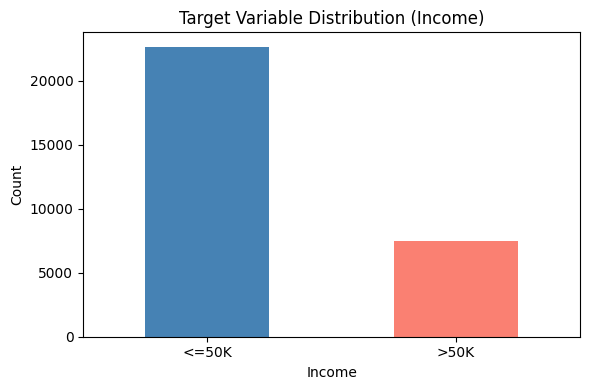

In [18]:
# Visualize
plt.figure(figsize=(6, 4))
df['income'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Variable Distribution (Income)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=150)
plt.show()

## Step 4 — Label Encoding
Label Encoding converts each unique category into a number.
We apply it on `marital_status` column.

In [19]:
from sklearn.preprocessing import LabelEncoder

# Copy column to avoid changing original
le = LabelEncoder()

df['marital_status_label'] = le.fit_transform(df['marital_status'])

# Show mapping
print("Label Encoding Mapping:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"  {original} → {encoded}")

Label Encoding Mapping:
  Divorced → 0
  Married-AF-spouse → 1
  Married-civ-spouse → 2
  Married-spouse-absent → 3
  Never-married → 4
  Separated → 5
  Widowed → 6


In [20]:
# Before vs After
print("Before vs After:\n")
print(df[['marital_status', 'marital_status_label']].head(10))

Before vs After:

   marital_status  marital_status_label
1         Widowed                     6
3        Divorced                     0
4       Separated                     5
5        Divorced                     0
6       Separated                     5
7   Never-married                     4
8        Divorced                     0
10       Divorced                     0
11  Never-married                     4
12        Widowed                     6


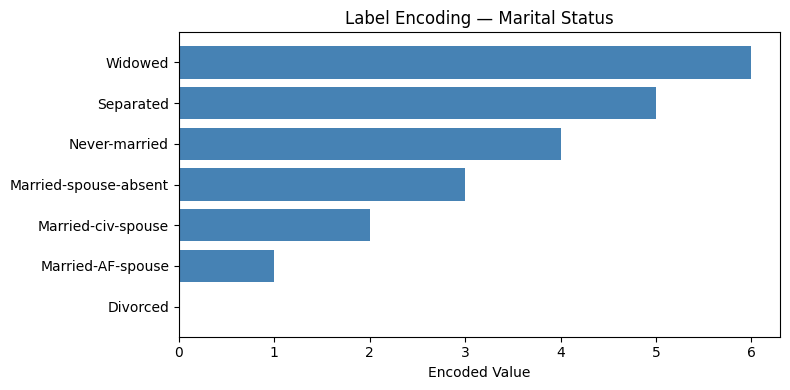

In [21]:
# Visualize label encoding
plt.figure(figsize=(8, 4))
mapping = dict(zip(le.classes_, range(len(le.classes_))))
plt.barh(list(mapping.keys()), list(mapping.values()), color='steelblue')
plt.title('Label Encoding — Marital Status')
plt.xlabel('Encoded Value')
plt.tight_layout()
plt.savefig('images/label_encoding.png', dpi=150)
plt.show()

## Step 5 — One-Hot Encoding
One-Hot Encoding creates a new binary column for each unique category.
We apply it on `workclass` and `sex` columns.

In [22]:
# One-Hot Encoding using pandas get_dummies
ohe_df = pd.get_dummies(df[['workclass', 'sex']], dtype=int)

print("Before — columns: workclass, sex")
print("After — new columns:")
print(ohe_df.columns.tolist())
print("\nShape:", ohe_df.shape)

Before — columns: workclass, sex
After — new columns:
['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'sex_Female', 'sex_Male']

Shape: (30162, 9)


In [23]:
# Before vs After
print("Sample output:\n")
print(ohe_df.head(5))

Sample output:

   workclass_Federal-gov  workclass_Local-gov  workclass_Private  \
1                      0                    0                  1   
3                      0                    0                  1   
4                      0                    0                  1   
5                      0                    0                  1   
6                      0                    0                  1   

   workclass_Self-emp-inc  workclass_Self-emp-not-inc  workclass_State-gov  \
1                       0                           0                    0   
3                       0                           0                    0   
4                       0                           0                    0   
5                       0                           0                    0   
6                       0                           0                    0   

   workclass_Without-pay  sex_Female  sex_Male  
1                      0           1         0  
3       

In [24]:
# Before vs After
print("Sample output:\n")
print(ohe_df.head(5).to_string())

Sample output:

   workclass_Federal-gov  workclass_Local-gov  workclass_Private  workclass_Self-emp-inc  workclass_Self-emp-not-inc  workclass_State-gov  workclass_Without-pay  sex_Female  sex_Male
1                      0                    0                  1                       0                           0                    0                      0           1         0
3                      0                    0                  1                       0                           0                    0                      0           1         0
4                      0                    0                  1                       0                           0                    0                      0           1         0
5                      0                    0                  1                       0                           0                    0                      0           1         0
6                      0                    0                  1     

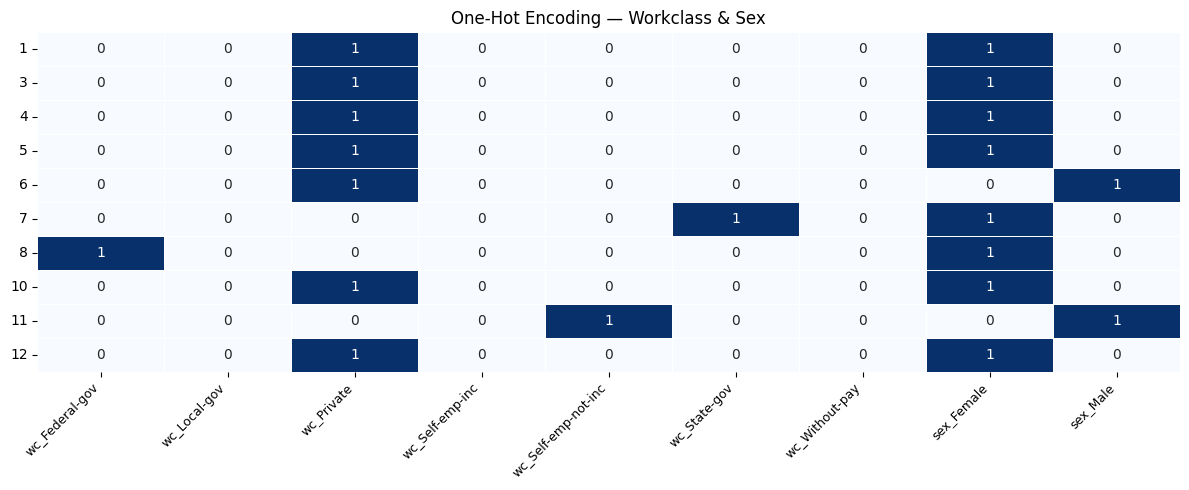

In [26]:
# Better visualization
plt.figure(figsize=(12, 5))
sns.heatmap(ohe_df.head(10), 
            annot=True, 
            cbar=False, 
            cmap='Blues', 
            linewidths=0.5,
            xticklabels=[col.replace('workclass_', 'wc_') for col in ohe_df.columns])
plt.title('One-Hot Encoding — Workclass & Sex')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('images/onehot_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Dummy Encoding
Dummy Encoding is similar to One-Hot but drops one column to avoid multicollinearity.
n categories → n-1 binary columns.
We apply it on `relationship` column.


In [27]:
# Dummy Encoding - drop_first=True drops one column
dummy_df = pd.get_dummies(df[['relationship']], drop_first=True, dtype=int)

print("Original unique values:", df['relationship'].nunique())
print("New columns after Dummy Encoding:", dummy_df.shape[1])
print("\nColumns:", dummy_df.columns.tolist())

Original unique values: 6
New columns after Dummy Encoding: 5

Columns: ['relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife']


In [28]:
# Sample output
print(dummy_df.head(8).to_string())

    relationship_Not-in-family  relationship_Other-relative  relationship_Own-child  relationship_Unmarried  relationship_Wife
1                            1                            0                       0                       0                  0
3                            0                            0                       0                       1                  0
4                            0                            0                       1                       0                  0
5                            0                            0                       0                       1                  0
6                            0                            0                       0                       1                  0
7                            0                            1                       0                       0                  0
8                            1                            0                       0                       0    

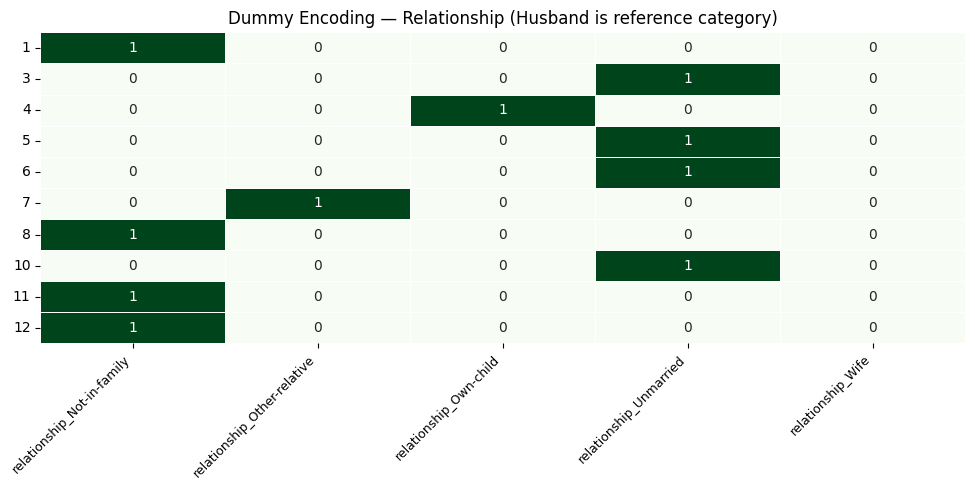

In [29]:
# Visualize dummy encoding
plt.figure(figsize=(10, 5))
sns.heatmap(dummy_df.head(10),
            annot=True,
            cbar=False,
            cmap='Greens',
            linewidths=0.5)
plt.title('Dummy Encoding — Relationship (Husband is reference category)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('images/dummy_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Ordinal Encoding
Ordinal Encoding assigns numbers based on meaningful order.
Unlike Label Encoding, we manually define the order.
We apply it on `education` column which has a clear ranking.

In [30]:
from sklearn.preprocessing import OrdinalEncoder

# Define meaningful order for education
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th',
    '10th', '11th', '12th', 'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

oe = OrdinalEncoder(categories=[education_order])
df['education_ordinal'] = oe.fit_transform(df[['education']])

print("Ordinal Encoding Mapping:")
for i, edu in enumerate(education_order):
    print(f"  {edu} → {i}")

Ordinal Encoding Mapping:
  Preschool → 0
  1st-4th → 1
  5th-6th → 2
  7th-8th → 3
  9th → 4
  10th → 5
  11th → 6
  12th → 7
  HS-grad → 8
  Some-college → 9
  Assoc-voc → 10
  Assoc-acdm → 11
  Bachelors → 12
  Masters → 13
  Prof-school → 14
  Doctorate → 15


In [31]:
# Before vs After
print("\nBefore vs After:\n")
print(df[['education', 'education_ordinal']].drop_duplicates().sort_values('education_ordinal').to_string())



Before vs After:

         education  education_ordinal
1106     Preschool                0.0
26         1st-4th                1.0
27         5th-6th                2.0
3          7th-8th                3.0
197            9th                4.0
6             10th                5.0
16            11th                6.0
178           12th                7.0
1          HS-grad                8.0
4     Some-college                9.0
25       Assoc-voc               10.0
60      Assoc-acdm               11.0
12       Bachelors               12.0
13         Masters               13.0
11     Prof-school               14.0
7        Doctorate               15.0


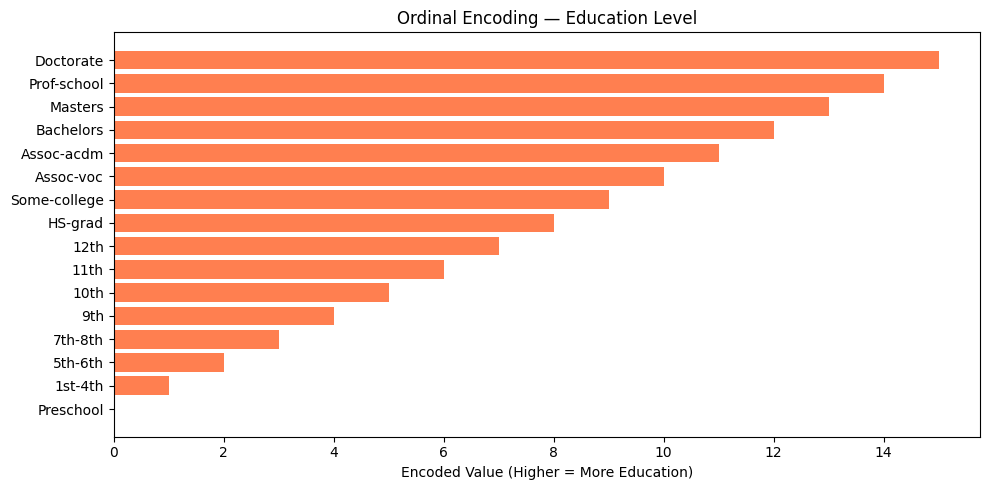

In [32]:
# Visualize ordinal encoding
plt.figure(figsize=(10, 5))
edu_mapping = dict(zip(education_order, range(len(education_order))))
plt.barh(list(edu_mapping.keys()), list(edu_mapping.values()), color='coral')
plt.title('Ordinal Encoding — Education Level')
plt.xlabel('Encoded Value (Higher = More Education)')
plt.tight_layout()
plt.savefig('images/ordinal_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Frequency Encoding
Frequency Encoding replaces each category with how often it appears in the dataset.
We apply it on `native_country` column which has 41 unique values.

In [33]:
# Frequency Encoding
freq_map = df['native_country'].value_counts()

df['native_country_freq'] = df['native_country'].map(freq_map)

print("Frequency Mapping (top 10):")
print(freq_map.head(10))

Frequency Mapping (top 10):
native_country
United-States    27504
Mexico             610
Philippines        188
Germany            128
Puerto-Rico        109
Canada             107
India              100
El-Salvador        100
Cuba                92
England             86
Name: count, dtype: int64


In [34]:
# Before vs After
print("\nBefore vs After:\n")
print(df[['native_country', 'native_country_freq']].drop_duplicates().sort_values('native_country_freq', ascending=False).head(10).to_string())


Before vs After:

     native_country  native_country_freq
1     United-States                27504
26           Mexico                  610
95      Philippines                  188
412         Germany                  128
216     Puerto-Rico                  109
157          Canada                  107
1315    El-Salvador                  100
90            India                  100
726            Cuba                   92
287         England                   86


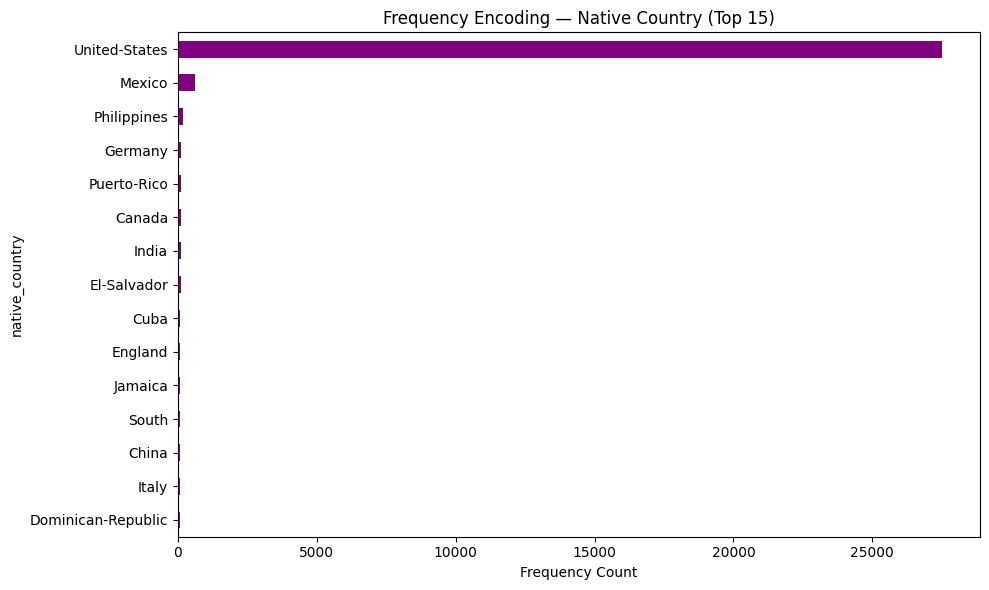

In [35]:
# Visualize frequency encoding - top 15 countries
plt.figure(figsize=(10, 6))
freq_map.head(15).plot(kind='barh', color='purple')
plt.title('Frequency Encoding — Native Country (Top 15)')
plt.xlabel('Frequency Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/frequency_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Target Encoding
Target Encoding replaces each category with the mean of the target variable.
We apply it on `occupation` column using `income` as target.

In [36]:
# First convert income to binary
df['income_binary'] = (df['income'] == '>50K').astype(int)

# Target Encoding manually
target_map = df.groupby('occupation')['income_binary'].mean()

df['occupation_target'] = df['occupation'].map(target_map)

print("Target Encoding Mapping (occupation → mean income >50K):")
print(target_map.sort_values(ascending=False).round(3))

Target Encoding Mapping (occupation → mean income >50K):
occupation
Exec-managerial      0.485
Prof-specialty       0.448
Protective-serv      0.326
Tech-support         0.305
Sales                0.271
Craft-repair         0.225
Transport-moving     0.203
Adm-clerical         0.134
Machine-op-inspct    0.125
Farming-fishing      0.116
Armed-Forces         0.111
Handlers-cleaners    0.061
Other-service        0.041
Priv-house-serv      0.007
Name: income_binary, dtype: float64


In [37]:
# Before vs After
print("\nBefore vs After:\n")
print(df[['occupation', 'occupation_target']].drop_duplicates().sort_values('occupation_target', ascending=False).to_string())


Before vs After:

             occupation  occupation_target
1       Exec-managerial           0.485220
4        Prof-specialty           0.448489
57      Protective-serv           0.326087
52         Tech-support           0.304825
19                Sales           0.270647
25         Craft-repair           0.225310
16     Transport-moving           0.202926
6          Adm-clerical           0.133835
3     Machine-op-inspct           0.124619
47      Farming-fishing           0.116279
850        Armed-Forces           0.111111
145   Handlers-cleaners           0.061481
5         Other-service           0.041096
1223    Priv-house-serv           0.006993


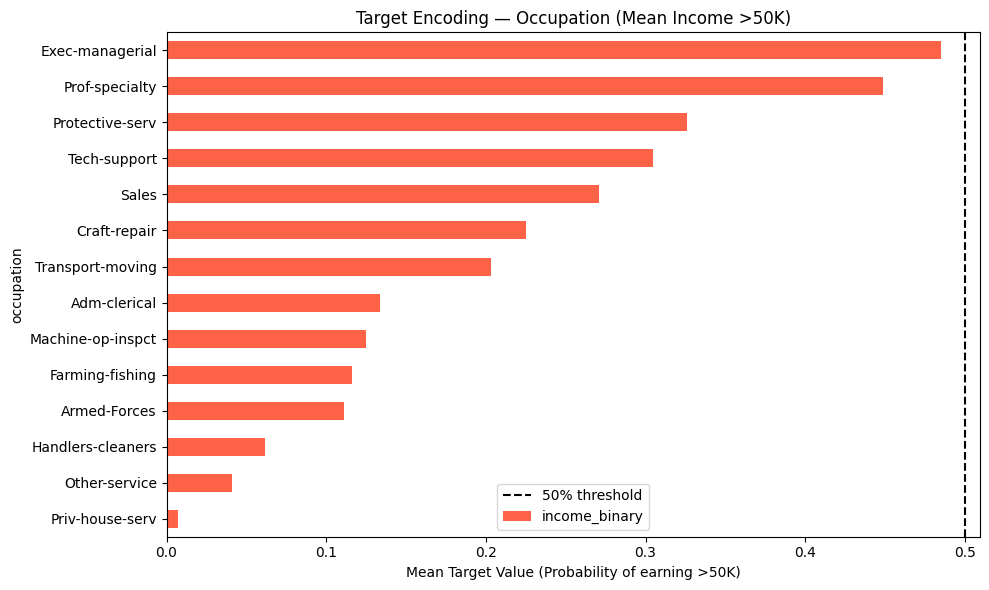

In [38]:
# Visualize target encoding
plt.figure(figsize=(10, 6))
target_map.sort_values().plot(kind='barh', color='tomato')
plt.title('Target Encoding — Occupation (Mean Income >50K)')
plt.xlabel('Mean Target Value (Probability of earning >50K)')
plt.axvline(x=0.5, color='black', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('images/target_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Binary Encoding
Binary Encoding converts categories to numbers then to binary representation.
n categories → log2(n) columns only.
We apply it on `race` column (5 categories → 3 columns).

In [39]:
import category_encoders as ce

# Binary Encoding
be = ce.BinaryEncoder(cols=['race'])
race_binary = be.fit_transform(df[['race']])

print("Original unique values:", df['race'].nunique())
print("New columns after Binary Encoding:", race_binary.shape[1])
print("\nColumns:", race_binary.columns.tolist())

Original unique values: 5
New columns after Binary Encoding: 3

Columns: ['race_0', 'race_1', 'race_2']


In [40]:
# Before vs After
race_compare = df[['race']].copy()
race_compare = pd.concat([race_compare, race_binary], axis=1)
print(race_compare.drop_duplicates().sort_values('race').to_string())

                   race  race_0  race_1  race_2
341  Amer-Indian-Eskimo       1       0       1
47   Asian-Pac-Islander       0       1       1
10                Black       0       1       0
216               Other       1       0       0
1                 White       0       0       1


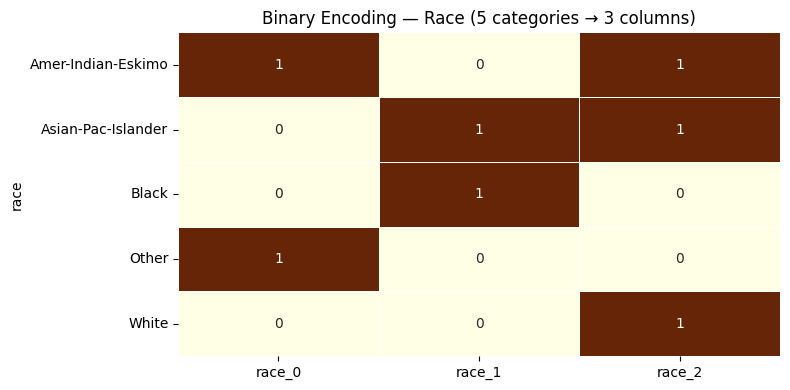

In [41]:
# Visualize binary encoding
plt.figure(figsize=(8, 4))
race_unique = race_compare.drop_duplicates().sort_values('race').set_index('race')
sns.heatmap(race_unique, 
            annot=True, 
            cbar=False, 
            cmap='YlOrBr',
            linewidths=0.5,
            fmt='d')
plt.title('Binary Encoding — Race (5 categories → 3 columns)')
plt.tight_layout()
plt.savefig('images/binary_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Comparison Table

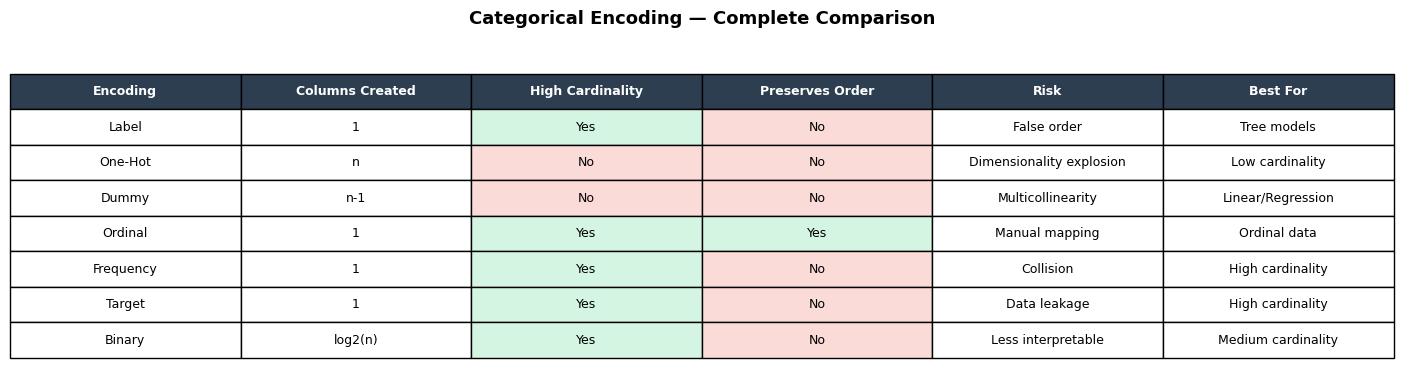

In [45]:
# Fixed comparison table
comparison = pd.DataFrame({
    'Encoding': ['Label', 'One-Hot', 'Dummy', 'Ordinal', 'Frequency', 'Target', 'Binary'],
    'Columns Created': ['1', 'n', 'n-1', '1', '1', '1', 'log2(n)'],
    'High Cardinality': ['Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Preserves Order': ['No', 'No', 'No', 'Yes', 'No', 'No', 'No'],
    'Risk': ['False order', 'Dimensionality explosion', 'Multicollinearity', 'Manual mapping', 'Collision', 'Data leakage', 'Less interpretable'],
    'Best For': ['Tree models', 'Low cardinality', 'Linear/Regression', 'Ordinal data', 'High cardinality', 'High cardinality', 'Medium cardinality']
})

# Plot table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2)

# Color header row
for j in range(len(comparison.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color Yes/No cells
for i in range(1, len(comparison) + 1):
    for j in [2, 3]:  # High Cardinality and Preserves Order columns
        cell = table[i, j]
        if cell.get_text().get_text() == 'Yes':
            cell.set_facecolor('#d5f5e3')
        else:
            cell.set_facecolor('#fadbd8')

plt.title('Categorical Encoding — Complete Comparison', 
          pad=20, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Cardinality Visualization
Visualizing unique values per categorical column helps us understand
why different encoding techniques are needed.

In [46]:
# Cardinality of each categorical column
cardinality = df[categorical_cols].nunique().sort_values(ascending=False)

print("Cardinality per categorical column:")
print(cardinality)

Cardinality per categorical column:
native_country    41
education         16
occupation        14
workclass          7
marital_status     7
relationship       6
race               5
sex                2
income             2
dtype: int64


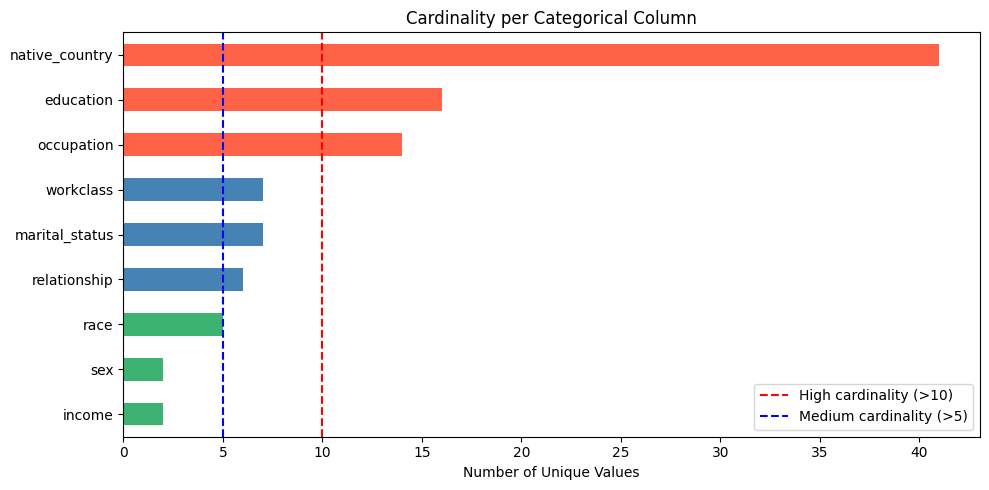

In [47]:
# Visualize cardinality
plt.figure(figsize=(10, 5))
colors = ['tomato' if v > 10 else 'steelblue' if v > 5 else 'mediumseagreen' 
          for v in cardinality.values]

cardinality.plot(kind='barh', color=colors)

# Add threshold lines
plt.axvline(x=10, color='red', linestyle='--', label='High cardinality (>10)')
plt.axvline(x=5, color='blue', linestyle='--', label='Medium cardinality (>5)')

plt.title('Cardinality per Categorical Column')
plt.xlabel('Number of Unique Values')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13 — Before vs After Encoding Summary
Showing original columns vs all encoded columns after transformation.

In [48]:
# Create final encoded dataframe
final_df = df[['age', 'fnlwgt', 'education_num', 
               'capital_gain', 'capital_loss', 'hours_per_week']].copy()

# Add all encoded columns
final_df['marital_status_label'] = df['marital_status_label']
final_df = pd.concat([final_df, ohe_df], axis=1)
final_df = pd.concat([final_df, dummy_df], axis=1)
final_df['education_ordinal'] = df['education_ordinal']
final_df['native_country_freq'] = df['native_country_freq']
final_df['occupation_target'] = df['occupation_target']
final_df = pd.concat([final_df, race_binary], axis=1)

print("Original shape:", df.shape)
print("Final encoded shape:", final_df.shape)
print("\nFinal columns:")
print(final_df.columns.tolist())

Original shape: (30162, 20)
Final encoded shape: (30162, 27)

Final columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'marital_status_label', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'sex_Female', 'sex_Male', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'education_ordinal', 'native_country_freq', 'occupation_target', 'race_0', 'race_1', 'race_2']


In [49]:
# Summary table
summary = pd.DataFrame({
    'Original Column': ['marital_status', 'workclass + sex', 
                        'relationship', 'education', 
                        'native_country', 'occupation', 'race'],
    'Encoding Used': ['Label', 'One-Hot', 'Dummy', 
                      'Ordinal', 'Frequency', 'Target', 'Binary'],
    'Original Columns': [1, 2, 1, 1, 1, 1, 1],
    'After Encoding': [1, 9, 5, 1, 1, 1, 3]
})

print(summary.to_string(index=False))

Original Column Encoding Used  Original Columns  After Encoding
 marital_status         Label                 1               1
workclass + sex       One-Hot                 2               9
   relationship         Dummy                 1               5
      education       Ordinal                 1               1
 native_country     Frequency                 1               1
     occupation        Target                 1               1
           race        Binary                 1               3


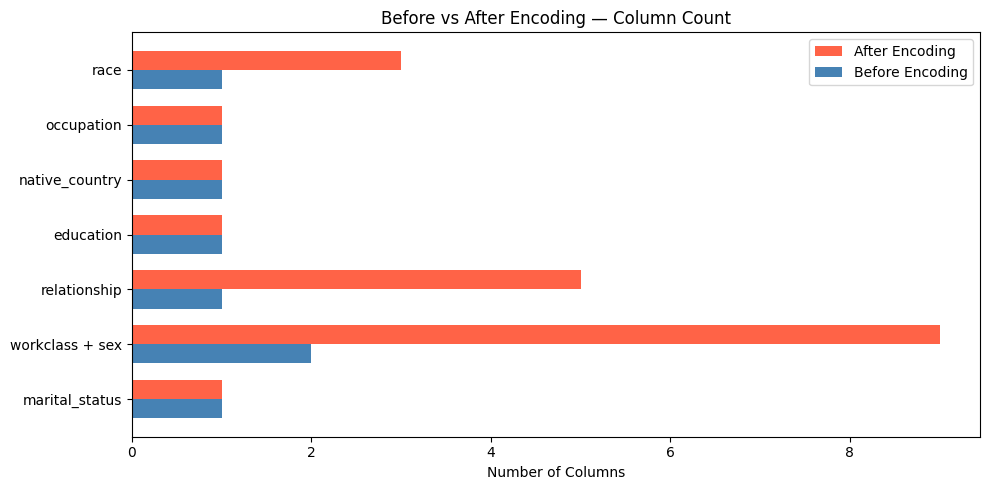

In [50]:
# Visualize before vs after columns
plt.figure(figsize=(10, 5))
x = range(len(summary))
width = 0.35

plt.barh([i + width/2 for i in x], summary['After Encoding'], 
         width, label='After Encoding', color='tomato')
plt.barh([i - width/2 for i in x], summary['Original Columns'], 
         width, label='Before Encoding', color='steelblue')

plt.yticks(x, summary['Original Column'])
plt.xlabel('Number of Columns')
plt.title('Before vs After Encoding — Column Count')
plt.legend()
plt.tight_layout()
plt.savefig('images/before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14 — Decision Flowchart
"Which encoding should I use?" — A visual guide.

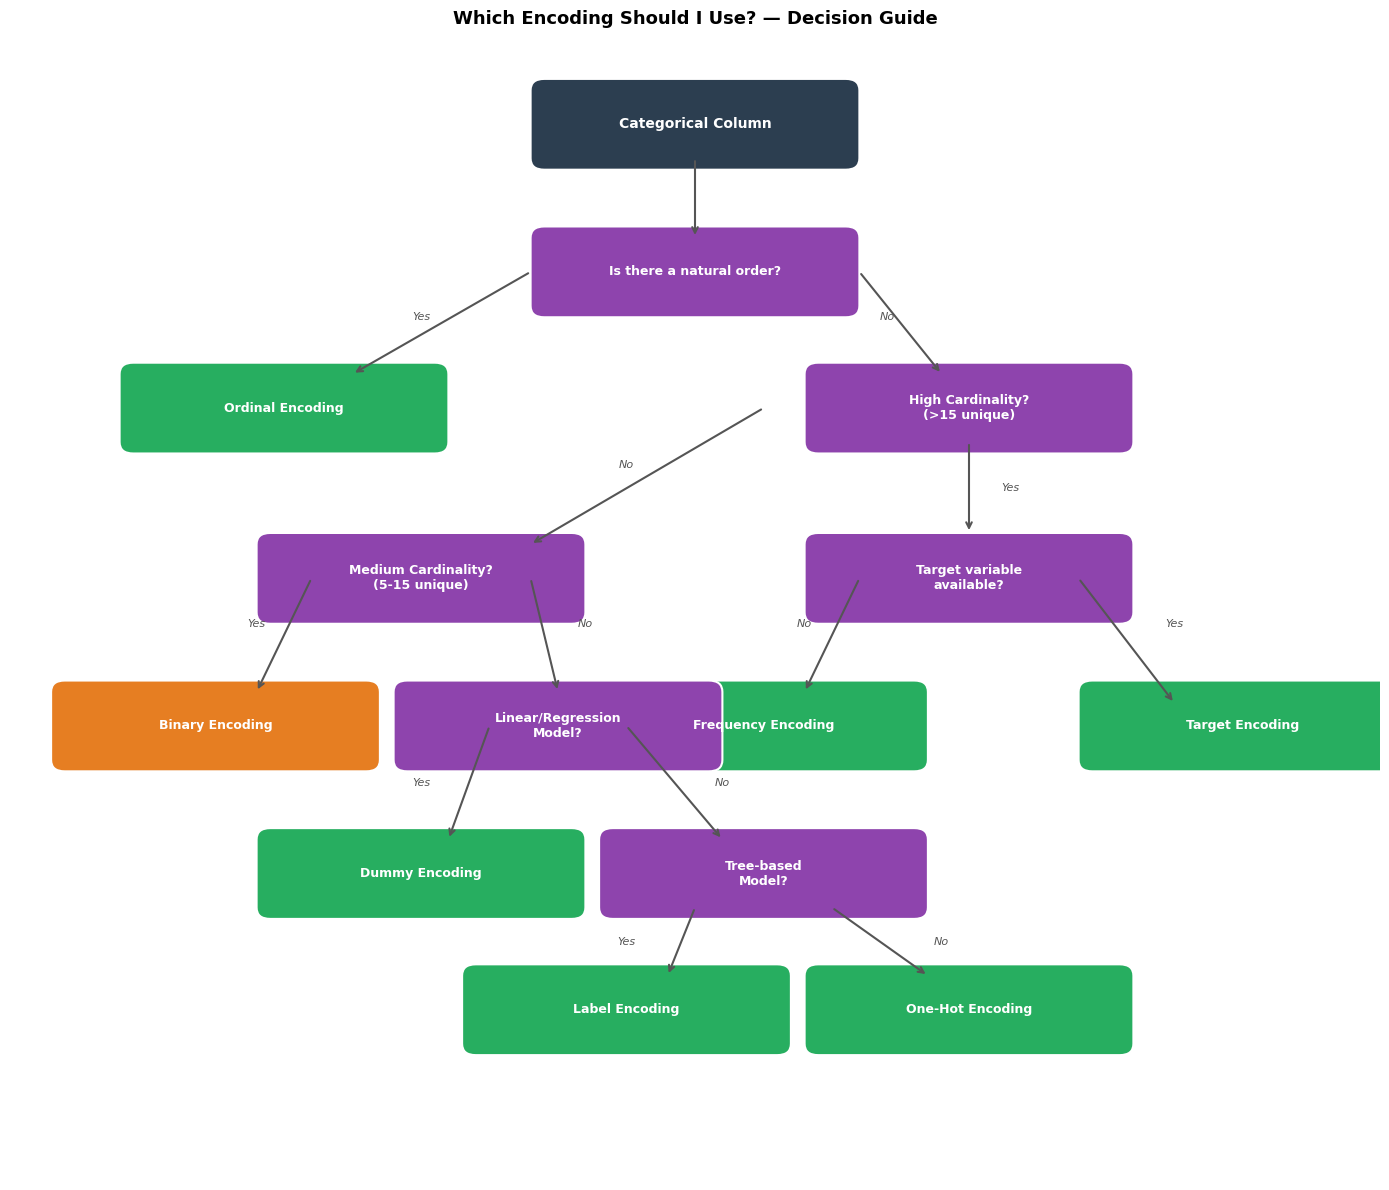

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

def draw_box(x, y, text, color='#2c3e50', textcolor='white',
             fontsize=9, width=2.2, height=0.6):
    box = mpatches.FancyBboxPatch(
        (x - width/2, y - height/2), width, height,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='white', linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=textcolor,
            fontweight='bold', wrap=True)

def draw_arrow(x1, y1, x2, y2):
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5)
    )

def draw_label(x, y, text):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=8, color='#555555', style='italic')

# Nodes
draw_box(5, 9.3, 'Categorical Column', '#2c3e50', fontsize=10)

# Q1 - Natural order?
draw_box(5, 8.0, 'Is there a natural order?', '#8e44ad')
draw_arrow(5, 9.0, 5, 8.3)

# Yes → Ordinal
draw_box(2, 6.8, 'Ordinal Encoding', '#27ae60')
draw_arrow(3.8, 8.0, 2.5, 7.1)
draw_label(3.0, 7.6, 'Yes')

# No → Q2 High Cardinality?
draw_box(7, 6.8, 'High Cardinality?\n(>15 unique)', '#8e44ad')
draw_arrow(6.2, 8.0, 6.8, 7.1)
draw_label(6.4, 7.6, 'No')

# High cardinality Yes → Q3 Target available?
draw_box(7, 5.3, 'Target variable\navailable?', '#8e44ad')
draw_arrow(7, 6.5, 7, 5.7)
draw_label(7.3, 6.1, 'Yes')

# Target Yes → Target Encoding
draw_box(9, 4.0, 'Target Encoding', '#27ae60')
draw_arrow(7.8, 5.3, 8.5, 4.2)
draw_label(8.5, 4.9, 'Yes')

# Target No → Frequency
draw_box(5.5, 4.0, 'Frequency Encoding', '#27ae60')
draw_arrow(6.2, 5.3, 5.8, 4.3)
draw_label(5.8, 4.9, 'No')

# High cardinality No → Q4 Medium Cardinality?
draw_box(3, 5.3, 'Medium Cardinality?\n(5-15 unique)', '#8e44ad')
draw_arrow(5.5, 6.8, 3.8, 5.6)
draw_label(4.5, 6.3, 'No')

# Medium cardinality Yes → Binary
draw_box(1.5, 4.0, 'Binary Encoding', '#e67e22')
draw_arrow(2.2, 5.3, 1.8, 4.3)
draw_label(1.8, 4.9, 'Yes')

# Medium cardinality No → Q5 Linear Model?
draw_box(4, 4.0, 'Linear/Regression\nModel?', '#8e44ad')
draw_arrow(3.8, 5.3, 4.0, 4.3)
draw_label(4.2, 4.9, 'No')

# Linear Yes → Dummy
draw_box(3, 2.7, 'Dummy Encoding', '#27ae60')
draw_arrow(3.5, 4.0, 3.2, 3.0)
draw_label(3.0, 3.5, 'Yes')

# Linear No → Q6 Tree Model?
draw_box(5.5, 2.7, 'Tree-based\nModel?', '#8e44ad')
draw_arrow(4.5, 4.0, 5.2, 3.0)
draw_label(5.2, 3.5, 'No')

# Tree Yes → Label
draw_box(4.5, 1.5, 'Label Encoding', '#27ae60')
draw_arrow(5.0, 2.4, 4.8, 1.8)
draw_label(4.5, 2.1, 'Yes')

# Tree No → One-Hot
draw_box(7, 1.5, 'One-Hot Encoding', '#27ae60')
draw_arrow(6.0, 2.4, 6.7, 1.8)
draw_label(6.8, 2.1, 'No')

plt.title(
    'Which Encoding Should I Use? — Decision Guide',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('images/decision_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — Verify Modular Code
Testing all imports from src/ modules.

In [53]:
# Test all imports from src/
from src.data_loader import load_and_prepare
from src.encoders import label_encode
from src.compare import print_encoding_summary

print_encoding_summary()
print("All imports working successfully!")


    ╔══════════════════════════════════════════════════════════════╗
    ║         CATEGORICAL ENCODING — QUICK REFERENCE              ║
    ╠══════════════════════════════════════════════════════════════╣
    ║  Label      → Tree models, avoid for linear models          ║
    ║  One-Hot    → Low cardinality (< 10 unique values)          ║
    ║  Dummy      → Linear/Regression models                      ║
    ║  Ordinal    → When natural order exists (education, rating)  ║
    ║  Frequency  → High cardinality, no target variable          ║
    ║  Target     → High cardinality, supervised learning         ║
    ║  Binary     → Medium cardinality, memory efficient          ║
    ╚══════════════════════════════════════════════════════════════╝
    
All imports working successfully!
